<a href="https://colab.research.google.com/github/3larios/PBL_FASE4/blob/main/PBL_FASE4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [ ]:
url_p3 = "https://raw.githubusercontent.com/3larios/PBL_FASE4/refs/heads/main/query3.csv"
url_p4 = "https://raw.githubusercontent.com/3larios/PBL_FASE4/refs/heads/main/query4.csv"
url_p5 = "https://raw.githubusercontent.com/3larios/PBL_FASE4/refs/heads/main/query5.csv"

df_pergunta3 = pd.read_csv(url_p3)
df_pergunta4 = pd.read_csv(url_p4)
df_pergunta5 = pd.read_csv(url_p5)

print("Dados carregados com sucesso de forma 100% portátil!")

Dados carregados com sucesso de forma 100% portátil!


--- Média de Notas: Faixa Etária ---
          FAIXA_ETARIA NR_NOTA_AVALIACAO
          Jovens (<25)          0.000000
Adultos Jovens (25-39)          7.861111
       Adultos (40-59)          7.400000
          Idosos (60+)          0.000000
-----------------------------------


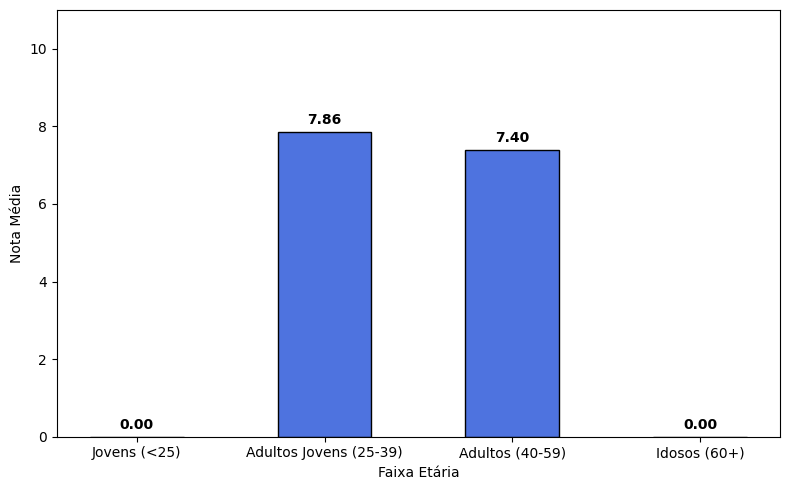

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Garante a conversão correta dos dados
df_pergunta3['NR_NOTA_AVALIACAO'] = pd.to_numeric(df_pergunta3['NR_NOTA_AVALIACAO'], errors='coerce')

# 2. Calcula a idade e define as 4 faixas obrigatórias
df_pergunta3['IDADE'] = 2026 - pd.to_datetime(df_pergunta3['DT_NASCIMENTO']).dt.year
condicoes = [
    (df_pergunta3['IDADE'] < 25),
    (df_pergunta3['IDADE'] >= 25) & (df_pergunta3['IDADE'] < 40),
    (df_pergunta3['IDADE'] >= 40) & (df_pergunta3['IDADE'] < 60),
    (df_pergunta3['IDADE'] >= 60)
]
escolhas = ['Jovens (<25)', 'Adultos Jovens (25-39)', 'Adultos (40-59)', 'Idosos (60+)']
df_pergunta3['FAIXA_ETARIA'] = np.select(condicoes, escolhas, default='Não Informado')

# 3. Calcula a média e garante a estrutura de texto limpa
analise_idade = df_pergunta3.groupby('FAIXA_ETARIA', observed=False)['NR_NOTA_AVALIACAO'].mean().reset_index()
analise_idade = analise_idade.set_index('FAIXA_ETARIA').reindex(escolhas).fillna(0).reset_index()

# Exibe a tabela de texto idêntica à pergunta 4
print("--- Média de Notas: Faixa Etária ---")
print(analise_idade.to_string(index=False, formatters={'NR_NOTA_AVALIACAO': '{:.6f}'.format}))
print("-" * 35)

# 4. Plota o gráfico ajustado para a escala de 0 a 10
plt.figure(figsize=(8, 5))
barras = plt.bar(analise_idade['FAIXA_ETARIA'], analise_idade['NR_NOTA_AVALIACAO'], color='#4e73df', width=0.5, edgecolor='black')

plt.ylim(0, 11)  # Ajustado para escala de até 10 pontos
plt.ylabel('Nota Média')
plt.xlabel('Faixa Etária')

# Adiciona as notas exatas no topo de cada barra
for b in barras:
    v = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

--- Média de Notas: Categoria vs Sexo ---
FL_SEXO                     F         M
DS_CATEGORIA                           
Alimentacao          9.312500  9.200000
Localizacao Publica  8.727273  9.166667
Museu                6.000000  2.600000
Parque               6.083333  4.142857
Shopping             7.417910  7.096774


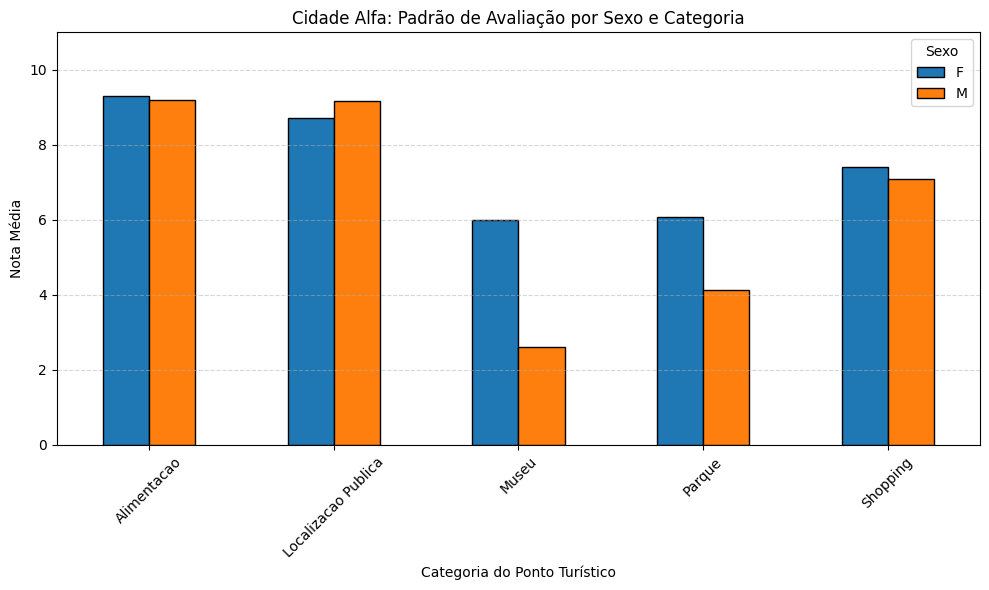

In [ ]:
analise_sexo_cat = df_pergunta4.groupby(['FL_SEXO', 'DS_CATEGORIA'])['NR_NOTA_AVALIACAO'].mean().unstack(level=0)
print("--- Média de Notas: Categoria vs Sexo ---")
print(analise_sexo_cat)

analise_sexo_cat.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('Cidade Alfa: Padrão de Avaliação por Sexo e Categoria')
plt.ylabel('Nota Média')
plt.xlabel('Categoria do Ponto Turístico')
plt.ylim(0, 11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

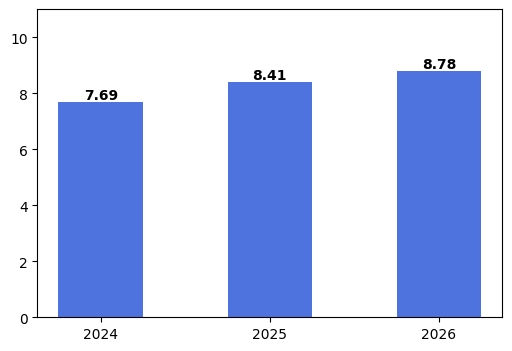

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_pergunta5['ANO'] = pd.to_datetime(df_pergunta5['DT_AVALIACAO']).dt.year
df_pergunta5['NR_NOTA_AVALIACAO'] = pd.to_numeric(df_pergunta5['NR_NOTA_AVALIACAO'], errors='coerce')
analise = df_pergunta5.groupby('ANO')['NR_NOTA_AVALIACAO'].mean().reset_index()

plt.figure(figsize=(6, 4))
barras = plt.bar(analise['ANO'].astype(str), analise['NR_NOTA_AVALIACAO'], color='#4e73df', width=0.5)

plt.ylim(0, 11)
for b in barras:
    v = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.show()

In [ ]:
!apt-get install redis-server -y > /dev/null
!service redis-server start > /dev/null
!pip install redis -q

import redis
import folium
import pandas as pd

r = redis.Redis(host='localhost', port=6379, decode_responses=True)
r.flushall()

pontos_unicos = df_pergunta4.drop_duplicates(subset=['NM_PONTO_TURISTICO'])

for _, linha in pontos_unicos.iterrows():
    nome_ponto = linha['NM_PONTO_TURISTICO']
    lon = float(linha['NR_LONGITUDE'])
    lat = float(linha['NR_LATITUDE'])

    r.geoadd("pontos_turisticos", (lon, lat, nome_ponto))

print("Dados de geolocalização indexados no Redis com sucesso!")

membros_redis = r.zrange("pontos_turisticos", 0, -1)
mapa = folium.Map(location=[df_pergunta4['NR_LATITUDE'].mean(), df_pergunta4['NR_LONGITUDE'].mean()], zoom_start=13)
for ponto in membros_redis:
    posicao = r.geopos("pontos_turisticos", ponto)[0]
    if posicao:
        lon_redis, lat_redis = posicao

        folium.Marker(
            location=[lat_redis, lon_redis],
            popup=ponto,
            icon=folium.Icon(color='red', icon='cloud')
        ).add_to(mapa)

mapa.save('mapa.html')
print("Arquivo 'mapa.html' atualizado consumindo dados do REDIS!")

Dados de geolocalização indexados no Redis com sucesso!
Arquivo 'mapa.html' atualizado consumindo dados do REDIS!
